# Segment a scene

Semantic segmentation labels every point in a scene / point cloud.
This notebook will guide you on how to use the `torch-pointcloud` library to load pretrained models and perform inference for semantic segmentation tasks. It will cover:

- the **model registry** and the `create_model` factory (the `timm`-style entry point),
- the **inferer API** to run a model over a large scene for inference.

## Setup

In [1]:
# On Colab:
# !pip install "torch-pointcloud"
# !pip install pyg-lib -f https://data.pyg.org/whl/torch-2.10.0+cu128.html

In [2]:
import torch

import torch_pointcloud as tp

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch-pointcloud", tp.__version__, "| device:", device)

torch-pointcloud 0.1.0 | device: cuda


## Load a sample scene

First, let's read a room of the [`ScanNet20`](../api/datasets/scannet.md) validation set, which we will use throughout this notebook. ScanNet requires a signed agreement: request it on its [download page](https://kaldir.vc.in.tum.de/scannet/) and extract it under `data/ScanNet/raw/`.

In [3]:
from torch_pointcloud.datasets import ScanNet20

dataset = ScanNet20(root="data", split="val")

Let's load the sample scene and visualize it. The room is a ScanNet scene kept as the vertices of its reconstructed mesh, with a color, a normal and a semantic id of the 20-class benchmark per vertex. One thing is still missing before the checkpoint can read it: the scene has to be voxelized.

In [4]:
import numpy as np


def load_sample():
    # Keep the per-point tensors of the first room
    return {key: value for key, value in dataset[0].items() if torch.is_tensor(value)}


In [5]:
import matplotlib.pyplot as plt


# View defined as: (elevation, azimuth)
ROOM_VIEW = (34, -160) 


def show_cloud(pos, color=None, *, ax=None, title=None, size=1, cmap="viridis", view=ROOM_VIEW):
    """Scatter a point cloud. `pos` is (N, 3); `color` is per-point RGB, a label vector, or None."""
    if ax is None:
        ax = plt.figure(figsize=(4, 4)).add_subplot(projection="3d")

    p = pos.detach().cpu().numpy()
    c = color.detach().cpu().numpy() if torch.is_tensor(color) else color
    kw = {"cmap": cmap} if c is not None and np.ndim(c) == 1 else {}
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)
    ax.view_init(elev=view[0], azim=view[1])
    ax.set_box_aspect(p.max(axis=0) - p.min(axis=0), zoom=1.6)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax


<Axes3D: title={'center': 'Sample scene'}>

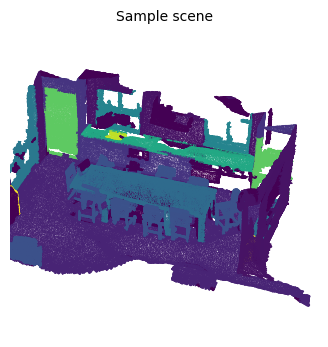

In [6]:
data = load_sample()
show_cloud(data["pos"], data["segment"], title="Sample scene")

## Find a model in the registry

Models are built by name through a single factory, `create_model`, mirroring `timm.create_model`. Names follow the pattern `<arch>-<variant>.<dataset>.<author>`.

You can list what is available for a task with `list_models` (it accepts a glob pattern):

In [7]:
from torch_pointcloud.models import list_models

list_models("*pointcept*", task="semantic-segmentation", pretrained=True)
# ['concerto-large-lp.scannet20.pointcept',
#  'ptv3-base.s3dis-area5.pointcept',
#  'ptv3-base.scannet20.pointcept',
#  'ptv3-base.scannet200.pointcept',
#  'spunet-v1m1.scannet20.pointcept',
#  'utonia-lp.scannet20.pointcept']

['concerto-large-lp.scannet20.pointcept',
 'ptv3-base.s3dis-area5.pointcept',
 'ptv3-base.scannet20.pointcept',
 'ptv3-base.scannet200.pointcept',
 'spunet-v1m1.scannet20.pointcept',
 'utonia-lp.scannet20.pointcept']

`create_model` returns a typed `SemanticSegmentationModel`, a regular `torch.nn.Module`, so `.eval()` and `.to(device)` work as usual.

In [8]:
model, info = tp.create_model(
    "spunet-v1m1.scannet20.pointcept",
    task="semantic-segmentation",
    pretrained=True,
    return_info=True,
)
model = model.eval().to(device)
# On Colab: !pip install "torch-pointcloud"
# On Colab: !pip install pyg-lib -f https://data.pyg.org/whl/torch-2.10.0+cu128.html
classes = list(info["weights"]["classes"])
print(len(classes), "classes:", ", ".join(classes))

20 classes: wall, floor, cabinet, bed, chair, sofa, table, door, window, bookshelf, picture, counter, desk, curtain, refrigerator, showercurtain, toilet, sink, bathtub, otherfurniture


## Run the model

A segmentation model is called as `model(x, pos, batch)`: features first, then coordinates, then the batch index. It returns a logits vector per point, shape $(N, C_\text{out})$.

However, SpUNet is a voxel backbone, so it never reads the raw points as floats: the model expects a voxelized scene.
This one was pretrained on ScanNet20 with scenes voxelized at 2 cm, and that transform is stored in the `info` dict (use `return_info=True` when creating the model to access it).

Note that the transform voxelizes the scene in place: `pos`, `x` and `segment` hold one entry per voxel, the raw cloud is kept under `origin_pos` / `origin_segment`, and `inverse` maps every raw point to its voxel.

In [9]:
from torch_pointcloud.utils.data import collate

data_list = [load_sample()]
data_list = [info["transform"](data) for data in data_list]
data = collate(data_list)

print(data.keys())
for key in data.keys():
    print(f"{key}: {data[key].shape}")

# dict_keys(['pos', 'color', 'normal', 'segment', 'instance', 'x', 'origin_pos', 'origin_segment', 'pos_grid', 'inverse', 'batch'])
# pos: torch.Size([164614, 3])           # One position per voxel
# color: torch.Size([164614, 3])         # Colors, one per voxel
# normal: torch.Size([164614, 3])        # Normals, one per voxel
# segment: torch.Size([164614])          # Labels, one per voxel
# instance: torch.Size([164614])         # Instance ids, one per voxel
# x: torch.Size([164614, 6])             # Voxelized features
# origin_pos: torch.Size([237360, 3])    # The original coordinates
# origin_segment: torch.Size([237360])   # The original labels
# pos_grid: torch.Size([164614, 3])      # Integer voxel-grid coordinates
# inverse: torch.Size([237360])          # Inverse mapping from raw points to voxels
# batch: torch.Size([164614])            # Batch index for each voxel

dict_keys(['pos', 'color', 'normal', 'segment', 'instance', 'x', 'origin_pos', 'origin_segment', 'pos_grid', 'inverse', 'batch'])
pos: torch.Size([164614, 3])
color: torch.Size([164614, 3])
normal: torch.Size([164614, 3])
segment: torch.Size([164614])
instance: torch.Size([164614])
x: torch.Size([164614, 6])
origin_pos: torch.Size([237360, 3])
origin_segment: torch.Size([237360])
pos_grid: torch.Size([164614, 3])
inverse: torch.Size([237360])
batch: torch.Size([164614])


In [10]:
model = model.eval().to(device)
with torch.no_grad():
    logits = model(data["x"].to(device), data["pos_grid"].to(device), data["batch"].to(device))

print("logits:", logits.shape)
# logits: torch.Size([164614, 20])

logits: torch.Size([164614, 20])


## Visualize the predictions

Turn logits into probabilities and map predicted labels (voxel-wise) to per-point labels. We will use the `inverse` key to map the logits back to the original points (revert the voxelization that occurred in the transforms).

In [11]:
logits = logits[data["inverse"].to(device)]
preds = logits.argmax(dim=-1).cpu()
print(f"logits.shape: {logits.shape}")
print(f"origin_pos.shape: {data['origin_pos'].shape}")


logits.shape: torch.Size([237360, 20])
origin_pos.shape: torch.Size([237360, 3])


In [12]:
from torch_pointcloud.metrics import accuracy, confusion_matrix, intersection_over_union

target = data["origin_segment"]
annotated = target >= 0
cm = confusion_matrix(preds, target, model.num_classes, ignore_index=-1)
iou = intersection_over_union(cm, average="none", zero_division=float("nan"))
involved = ~iou.isnan()

print(f"annotated points: {int(annotated.sum())} of {len(target)}")
print(f"accuracy: {accuracy(cm):.3f}")
print(f"mIoU over the {int(involved.sum())} classes involved: {iou[involved].mean():.3f}")


annotated points: 194881 of 237360
accuracy: 0.886
mIoU over the 15 classes involved: 0.519


To see *where* the model is wrong, color the room by whether each point came back right, and put the per-class IoU next to it. The pale points are the ones the room carries no label for, which both metrics leave out through `ignore_index=-1`.


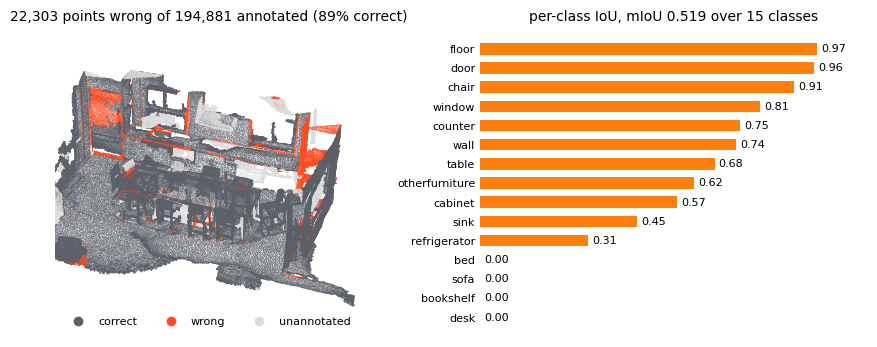

In [13]:
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

CORRECT, WRONG, UNANNOTATED = "#5c6068", "#ff4c22", "#dcdcdc"


def show_prediction(preds):
    """Color the room by whether each point came back right, beside the per-class IoU of that run."""
    cm = confusion_matrix(preds, target, model.num_classes, ignore_index=-1)
    iou = intersection_over_union(cm, average="none", zero_division=float("nan"))
    present = torch.nonzero(~iou.isnan()).flatten()
    ranked = present[iou[present].argsort(descending=True)]
    wrong = annotated & (preds != target)
    correct = accuracy(cm)

    fig = plt.figure(figsize=(11, 4))
    ax = show_cloud(
        data["origin_pos"],
        color=np.array([to_rgb(UNANNOTATED), to_rgb(CORRECT), to_rgb(WRONG)])[annotated.long() + wrong.long()],
        ax=fig.add_subplot(121, projection="3d"),
        title=f"{int(wrong.sum()):,} points wrong of {int(annotated.sum()):,} annotated ({correct:.0%} correct)",
        size=0.4,
    )
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", color=color, label=name)
            for name, color in (("correct", CORRECT), ("wrong", WRONG), ("unannotated", UNANNOTATED))
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=3,
        frameon=False,
        fontsize=8,
    )

    ax = fig.add_subplot(122)
    bars = ax.barh([classes[int(index)] for index in ranked], iou[ranked].tolist(), color="tab:orange", height=0.6)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0.0, 1.12)
    ax.set_xticks([])
    ax.tick_params(length=0, labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"per-class IoU, mIoU {iou[present].mean():.3f} over {len(present)} classes", fontsize=10)


show_prediction(preds)


![Prediction errors and per-class IoU](../assets/tutorials/segmentation_room_errors.png)

## Using an inferer

An [inferer](../inferers/overview.md) takes a packed-batch dict and a `predictor` callable, and returns one prediction per input point, shape $(N, C_\text{out})$, aligned to the input order.

### Simple Inferer

This inferer runs the predictor on the whole scene at once, so it is just a wrapper around the model's `forward` method, but it adheres to the inferer API.

In [14]:
from torch_pointcloud.inferers import SimpleInferer, SlidingWindowInferer

scene = collate([load_sample()])


def spunet_predictor(data):
    # Apply the inference transform to the specific input data
    data = info["transform"]({key: value.clone() for key, value in data.items() if torch.is_tensor(value)})
    pos_grid = data["pos_grid"].to(device)
    batch = torch.zeros(len(pos_grid), dtype=torch.long, device=device)
    logits = model(data["x"].to(device), pos_grid, batch)
    return logits[data["inverse"].to(device)].cpu()


In [15]:
inferer = SimpleInferer()
preds_whole = inferer(scene, predictor=spunet_predictor)
print("output:", tuple(preds_whole.shape))

output: (237360, 20)


### Sliding Window Inferer

When the scene is too large for one pass, `SlidingWindowInferer` tiles it into cubic blocks of a fixed metric size, runs the predictor on each, and blends overlapping predictions. With `mode="gaussian"` points near a block center count more than those at the seam, which softens block boundaries.


In [16]:
inferer = SlidingWindowInferer(block_size=2.0, overlap=0.25, mode="gaussian", softmax=True)
preds_tiled = inferer(scene, predictor=spunet_predictor)
print("output:", tuple(preds_tiled.shape))

output: (237360, 20)


labels that differ from the whole-scene run: 23625


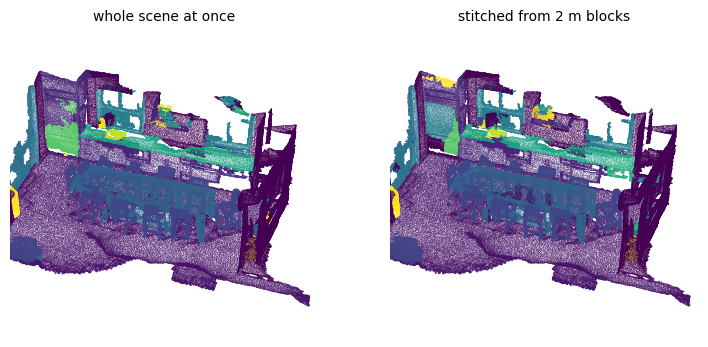

In [17]:
print("labels that differ from the whole-scene run:", int((preds_tiled.argmax(-1) != preds_whole.argmax(-1)).sum()))

fig = plt.figure(figsize=(9, 4))
show_cloud(data["origin_pos"], color=preds_whole.argmax(-1), ax=fig.add_subplot(121, projection="3d"), title="whole scene at once", size=0.4)
show_cloud(data["origin_pos"], color=preds_tiled.argmax(-1), ax=fig.add_subplot(122, projection="3d"), title="stitched from 2 m blocks", size=0.4);


### Test-time augmentation Inferer 

Test-time augmentation wraps a base inferer, runs several augmented passes over the input, and averages the predictions.

In [18]:
from torch_pointcloud.inferers import TTAInferer
from torch_pointcloud.transforms import RandomRotate

views = [
    RandomRotate(keys=("pos", "normal"), angle_range=(angle, angle), axis=2, p=1.0)
    for angle in (0.0, 90.0, 180.0, 270.0)
]
inferer = TTAInferer(base=SimpleInferer(softmax=True), transforms=views)
voted = inferer(scene, predictor=spunet_predictor).argmax(dim=-1).cpu()

cm = confusion_matrix(voted, target, model.num_classes, ignore_index=-1)
iou = intersection_over_union(cm, average="none", zero_division=float("nan"))
involved = ~iou.isnan()
print(f"accuracy: {accuracy(cm):.3f}")
print(f"mIoU over the {int(involved.sum())} classes involved: {iou[involved].mean():.3f}")


accuracy: 0.899
mIoU over the 15 classes involved: 0.546


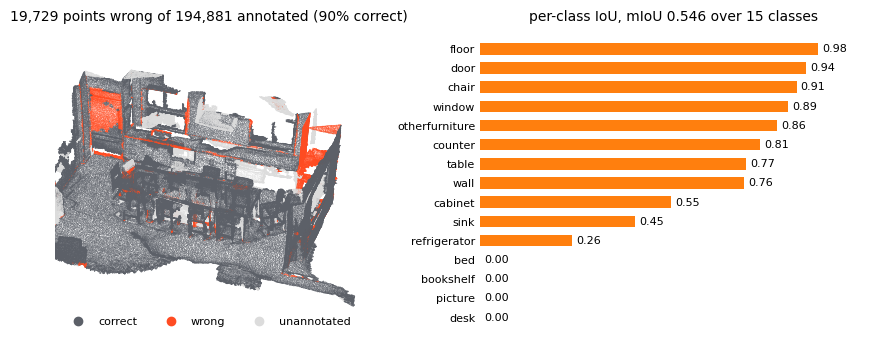

In [19]:
show_prediction(voted)

![Errors with test-time augmentation](../assets/tutorials/segmentation_tta_errors.png)

## Ensembling

The cell below ensembles two checkpoints: each runs through a `TTAInferer` wrapping a `SimpleInferer`, and their probabilities are averaged.

In [20]:
def probabilities(name):
    member, member_info = tp.create_model(name, task="semantic-segmentation", pretrained=True, return_info=True)
    member = member.eval().to(device)

    def predictor(data):
        window = member_info["transform"]({key: value.clone() for key, value in data.items() if torch.is_tensor(value)})
        pos_grid = window["pos_grid"].to(device)
        batch = torch.zeros(len(pos_grid), dtype=torch.long, device=device)
        logits = member(window["x"].to(device), pos_grid, batch)
        return logits[window["inverse"].to(device)]

    inferer = TTAInferer(
        base=SimpleInferer(softmax=True), 
        transforms=views
    )
    voted = inferer(scene, predictor=predictor)

    member.cpu()
    torch.cuda.empty_cache()
    return voted.cpu()


model_names = ("spunet-v1m1.scannet20.pointcept", "concerto-large-lp.scannet20.pointcept")
merged = torch.stack([probabilities(name) for name in model_names]).mean(dim=0).argmax(dim=-1)

cm = confusion_matrix(merged, target, model.num_classes, ignore_index=-1)
iou = intersection_over_union(cm, average="none", zero_division=float("nan"))
involved = ~iou.isnan()
print(f"accuracy: {accuracy(cm):.3f}")
print(f"mIoU over the {int(involved.sum())} classes involved: {iou[involved].mean():.3f}")


accuracy: 0.941
mIoU over the 12 classes involved: 0.777


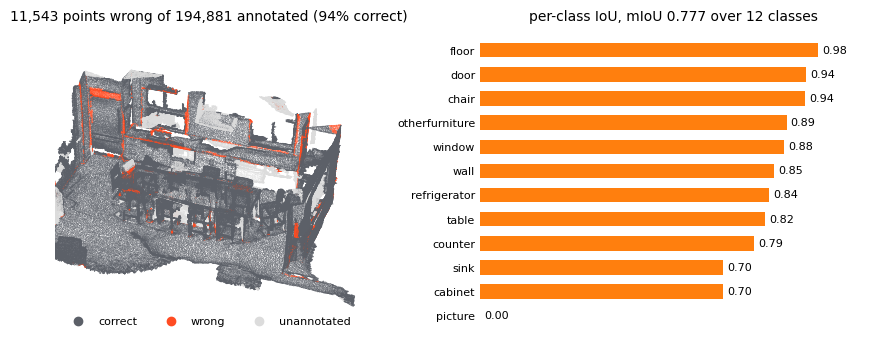

In [21]:
show_prediction(merged)

![Errors with a two-checkpoint ensemble](../assets/tutorials/segmentation_ensemble_errors.png)